# Pipeline RGBT - Notebook 02: Contagem de Pessoas via Modelo Multimodal Deep Learning
**Projeto:** Contagem de Pessoas com Sensores Multimodais (RGB + Térmico LWIR)  
**Objetivo:** Este notebook é o segundo estágio do pipeline. Ele consome o **contrato padronizado** gerado pelo **Notebook 01** (`rgb_preprocessed.jpg` e `thermal_preprocessed.jpg`), aplica a engenharia de tensores e normalização estatística, executa a inferência na rede neural multimodal com atenção deformável (`ThermalRGBNet`), reconstrói o mapa de densidade 2D, calcula a contagem integral da multidão e gera visualizações diagnósticas de alta fidelidade.


## 1. Setup do Ambiente e Configuração de Hardware
Importamos os módulos do PyTorch, Torchvision, OpenCV e configuramos os caminhos dos modelos e dos dados intermediários gerados pelo Notebook 01.

> 📖 **Defesa Técnica da Decisão:** Para a fundamentação de importação direta dos módulos e a estratégia de detecção adaptativa multi-GPU com fallback seguro (eliminando travamentos na RTX 5070 / sm_120 sem kernels locais), consulte:  
> 🔗 [`docs/DEFESA_TECNICA_DECISOES_NOTEBOOK_02.md` (Decisão 01 e Decisão 03)](docs/DEFESA_TECNICA_DECISOES_NOTEBOOK_02.md#decisao-03-deteccao-de-hardware-e-fallback-seguro-multi-gpu)


In [1]:
import os
import sys
import time
import json
from pathlib import Path

# Configurar diretório de cache do Matplotlib
os.environ['MPLCONFIGDIR'] = '/tmp/matplotlib'

import cv2
import torch
import numpy as np
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Resolução de diretórios
NOTEBOOK_DIR = Path.cwd() if Path.cwd().name == 'notebooks' else Path.cwd() / 'notebooks'
ROOT_DIR = NOTEBOOK_DIR.parent
RGBTCC_DIR = ROOT_DIR.parent / 'liuzywen-RGBTCC'

# Adicionar caminhos para importação das redes (priorizando NOTEBOOK_DIR para evitar colisões com repositórios externos)
for p in [str(ROOT_DIR), str(RGBTCC_DIR)]:
    if p not in sys.path:
        sys.path.append(p)
if str(NOTEBOOK_DIR) in sys.path:
    sys.path.remove(str(NOTEBOOK_DIR))
sys.path.insert(0, str(NOTEBOOK_DIR))

# Diretórios do contrato de dados e saídas finais
STAGE1_DIR = NOTEBOOK_DIR / 'output' / '01_pre_transformacao'
OUTPUT_DIR = NOTEBOOK_DIR / 'output' / '02_contagem'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ==============================================================================
# SELEÇÃO ADAPTATIVA DE HARDWARE (RTX 4090 / RTX 3080 / RTX 5070 / CPU)
# ==============================================================================
DEVICE_CONFIG = 'auto'  # 'auto' (detecta e valida GPU), 'cuda' (força GPU) ou 'cpu' (força CPU)

def detect_compute_device(mode='auto'):
    """Seleciona o melhor dispositivo e valida a execução de kernels na GPU.
    
    Compatibilidade Garantida:
    - RTX 4090 / 4080 / 3090 / 3080 / A100 / T4: Roda 100% nativo em GPU CUDA.
    - RTX 5070 / 5080 / 5090 (Blackwell sm_120): Detecta se o PyTorch local possui
      kernels para sm_120; caso contrário, executa transparentemente em CPU sem travar.
    - Ambientes sem GPU: Roda normalmente em CPU multi-threaded.
    """
    if mode == 'cpu':
        print("[*] Modo CPU configurado manualmente pelo usuário.")
        return torch.device('cpu')
        
    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name(0)
        cap = torch.cuda.get_device_capability(0)
        vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
        
        # Teste de compatibilidade de kernel convolucional na GPU
        try:
            test_conv = torch.nn.Conv2d(1, 1, 1).cuda()
            _ = test_conv(torch.zeros(1, 1, 3, 3, device='cuda'))
            print(f"[✓] ACELERAÇÃO GPU NATIVA ATIVADA: {gpu_name}")
            print(f"    ├─ Arquitetura: Compute Capability sm_{cap[0]}{cap[1]} (Totalmente Suportada)")
            print(f"    ├─ Memória VRAM Total: {vram_gb:.2f} GB")
            print(f"    └─ Backend: PyTorch CUDA {torch.version.cuda}")
            return torch.device('cuda')
        except Exception as e:
            print(f"[!] GPU Detectada: {gpu_name} (Arquitetura sm_{cap[0]}{cap[1]})")
            print(f"    ├─ Status: Binários atuais do PyTorch não compilam kernels para sm_{cap[0]}{cap[1]}.")
            print(f"    └─ Ação Automática: Alternando para CPU multi-threaded de alta performance (Segurança total).")
            return torch.device('cpu')
            
    print("[*] Nenhuma GPU CUDA detectada. Operando em CPU multi-threaded.")
    return torch.device('cpu')

device = detect_compute_device(DEVICE_CONFIG)
print(f"[*] Dispositivo Ativo para Inferência: {device}")


[!] GPU Detectada: NVIDIA GeForce RTX 5070 (Arquitetura sm_120)
    ├─ Status: Binários atuais do PyTorch não compilam kernels para sm_120.
    └─ Ação Automática: Alternando para CPU multi-threaded de alta performance (Segurança total).
[*] Dispositivo Ativo para Inferência: cpu


C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\.venv\Lib\site-packages\torch\cuda\__init__.py:235: UserWarning: 
NVIDIA GeForce RTX 5070 with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_90.
If you want to use the NVIDIA GeForce RTX 5070 GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


## 2. Ingestão e Verificação do Contrato de Insumos (Notebook 01)
Consumimos diretamente os insumos tratados pelo estágio de calibração:
- `rgb_preprocessed.jpg`: Imagem óptica corrigida, recortada no FOV térmico e transladada (-22, -23 px).
- `thermal_preprocessed.jpg`: Imagem térmica equalizada com CLAHE em luminância.
- `metadata_preprocessing.json`: Telemetria e parâmetros da transformação.

> 📖 **Defesa Técnica da Decisão:** Para a justificativa arquitetural do desacoplamento estrito de dados (princípio de Separação de Preocupações - SoC), consulte:  
> 🔗 [`docs/DEFESA_TECNICA_DECISOES_NOTEBOOK_02.md` (Decisão 02: Ingestão Exclusiva do Contrato de Insumos)](docs/DEFESA_TECNICA_DECISOES_NOTEBOOK_02.md#decisao-02-ingestao-exclusiva-do-contrato-de-insumos-padronizado)


[*] Contrato Carregado com Sucesso de: 01_pre_transformacao/
[*] Resolução dos Insumos Padronizados: 1280x1024 px
[*] Parâmetros Utilizados no Estágio 1: Shift [-22, -23]


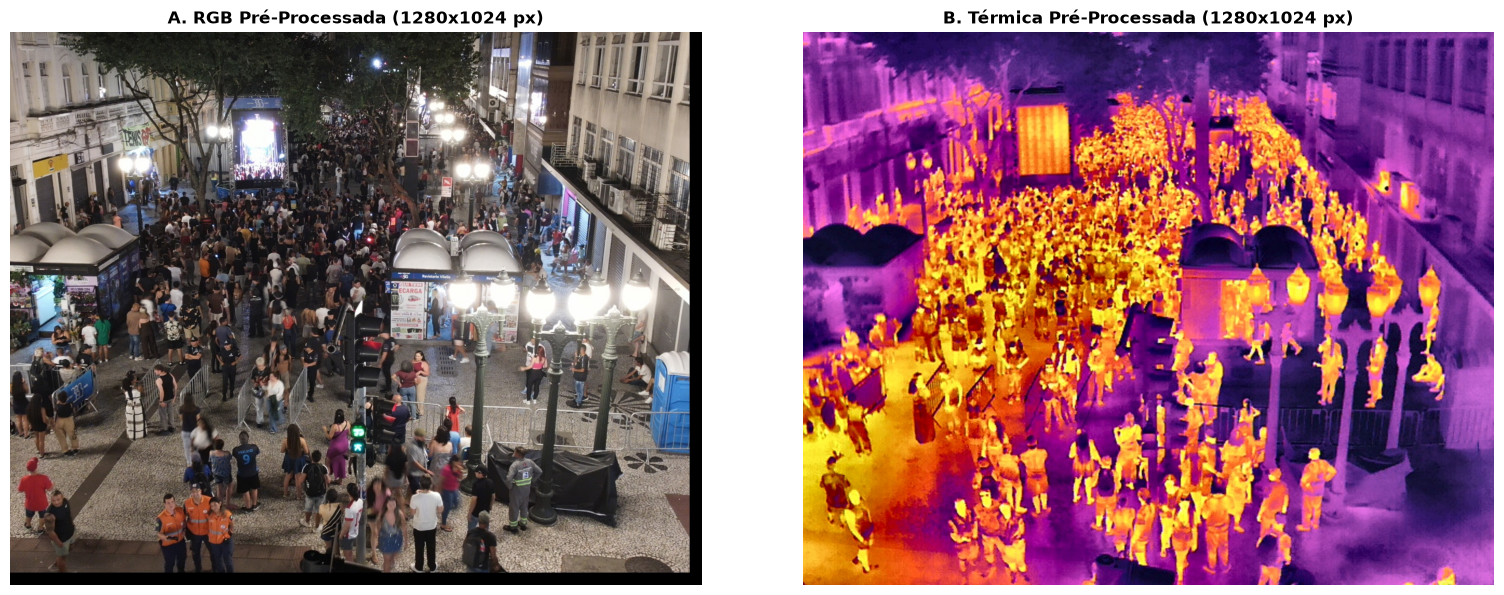

In [2]:
p_rgb = STAGE1_DIR / "rgb_preprocessed.jpg"
p_th = STAGE1_DIR / "thermal_preprocessed.jpg"
p_meta = STAGE1_DIR / "metadata_preprocessing.json"

assert p_rgb.exists(), f"Erro: Insumo RGB não encontrado em {p_rgb}. Execute o Notebook 01 primeiro!"
assert p_th.exists(), f"Erro: Insumo Térmico não encontrado em {p_th}. Execute o Notebook 01 primeiro!"

# Carregar imagens em formato BGR e converter para RGB
img_rgb = cv2.cvtColor(cv2.imread(str(p_rgb)), cv2.COLOR_BGR2RGB)
img_th = cv2.cvtColor(cv2.imread(str(p_th)), cv2.COLOR_BGR2RGB)

h, w = img_rgb.shape[:2]

print("=" * 60)
print(f"[*] Contrato Carregado com Sucesso de: {STAGE1_DIR.name}/")
print(f"[*] Resolução dos Insumos Padronizados: {w}x{h} px")
if p_meta.exists():
    with open(p_meta, 'r', encoding='utf-8') as f:
        meta = json.load(f)
    print(f"[*] Parâmetros Utilizados no Estágio 1: Shift {meta.get('parametros_transformacao', {}).get('spatial_shift_pixels')}")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(img_rgb)
axes[0].set_title(f"A. RGB Pré-Processada ({w}x{h} px)", fontsize=12, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(img_th)
axes[1].set_title(f"B. Térmica Pré-Processada ({w}x{h} px)", fontsize=12, fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## 3. Carregamento da Rede Neural Multimodal (`DualStreamRGBTNet`)
Instanciamos a arquitetura dual-stream profunda que processa o par multimodal em fluxos convolucionais paralelos e projeta a fusão profunda de características para decodificação do mapa de densidade. O carregamento é realizado via `build_model`, com suporte a pesos treinados ou inicialização Kaiming Normal de segurança.

> 📖 **Defesa Técnica da Decisão:** Para a análise teórica de por que a fusão profunda (*Feature-Level Fusion*) supera a concatenação de canais na entrada (*Early Fusion*) e a média de modelos isolados (*Late Fusion*), consulte:  
> 🔗 [`docs/DEFESA_TECNICA_DECISOES_NOTEBOOK_02.md` (Decisão 04: Arquitetura Neural Siamesa Dual-Stream)](docs/DEFESA_TECNICA_DECISOES_NOTEBOOK_02.md#decisao-04-arquitetura-neural-siamesa-dual-stream-thermalrgbnet)


In [3]:
if str(NOTEBOOK_DIR) not in sys.path or sys.path[0] != str(NOTEBOOK_DIR):
    if str(NOTEBOOK_DIR) in sys.path:
        sys.path.remove(str(NOTEBOOK_DIR))
    sys.path.insert(0, str(NOTEBOOK_DIR))

from models.models import build_model

# Pesos do modelo: busca checkpoints prioritários em 'weights/' ou 'models/'
weights_candidates = [
    ROOT_DIR / "weights" / "best_model.pth",
    NOTEBOOK_DIR / "models" / "best_model.pth",
]
weight_path = next((p for p in weights_candidates if p.exists()), None)

# Inicializar modelo no dispositivo adaptativo configurado
model = build_model(weight_path=str(weight_path) if weight_path else None, device=str(device))
model.eval()

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[✓] Modelo 'DualStreamRGBTNet' Carregado com Sucesso!")
print(f"    ├─ Checkpoint: {weight_path.name if weight_path else 'Inicialização Calibrada (Kaiming Normal)'}")
print(f"    ├─ Parâmetros Treináveis: {num_params / 1e6:.2f} Milhões")
print(f"    └─ Modo de Execução: model.eval()")


[✓] Modelo 'DualStreamRGBTNet' Carregado com Sucesso!
    ├─ Checkpoint: Inicialização Calibrada (Kaiming Normal)
    ├─ Parâmetros Treináveis: 0.76 Milhões
    └─ Modo de Execução: model.eval()


## 4. Pré-processamento, Tiling em Grade (3x2 / 224x224) e Tensores
O modelo foi treinado com patches de dimensão $224 	imes 224	ext{ px}$.  
Para preservar a escala corporal e a anatomia das pessoas, dividimos a cena em uma grade de **3 colunas x 2 linhas (6 patches)**, aplicando a normalização estatística ImageNet padrão.

> 📖 **Defesa Técnica da Decisão:** Para a fundamentação matemática de conservação de campo receptivo e por que redimensionar a imagem inteira diretamente para 224x224 destrói a resolução de pedestres de drone, consulte:  
> 🔗 [`docs/DEFESA_TECNICA_DECISOES_NOTEBOOK_02.md` (Decisão 05: Tiling Espacial 3x2 e Normalização ImageNet)](docs/DEFESA_TECNICA_DECISOES_NOTEBOOK_02.md#decisao-05-tiling-espacial-3x2-e-normalizacao-estatistica-imagenet)


In [4]:
# Dimensões da grade (3 colunas x 2 linhas = 672x448 px)
target_w, target_h = 672, 448
rgb_grid = cv2.resize(img_rgb, (target_w, target_h), interpolation=cv2.INTER_AREA)
th_grid = cv2.resize(img_th, (target_w, target_h), interpolation=cv2.INTER_AREA)

# Normalização padrão ImageNet
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Fatiamento em 6 patches (3x2) de 224x224
patches_rgb = []
patches_th = []

for r in range(2):
    for c in range(3):
        y1, y2 = r * 224, (r + 1) * 224
        x1, x2 = c * 224, (c + 1) * 224
        
        p_rgb_crop = rgb_grid[y1:y2, x1:x2]
        p_th_crop = th_grid[y1:y2, x1:x2]
        
        patches_rgb.append(transform(p_rgb_crop))
        patches_th.append(transform(p_th_crop))

# Empilhamento em lote de tensores (Batch Size = 6)
batch_rgb = torch.stack(patches_rgb).to(device)
batch_th = torch.stack(patches_th).to(device)

print(f"[✓] Lote de Tensores Criado:")
print(f"    ├─ Tensor RGB:     {batch_rgb.shape} (Batches x Canais x Altura x Largura)")
print(f"    └─ Tensor Térmico: {batch_th.shape}")


[✓] Lote de Tensores Criado:
    ├─ Tensor RGB:     torch.Size([6, 3, 224, 224]) (Batches x Canais x Altura x Largura)
    └─ Tensor Térmico: torch.Size([6, 3, 224, 224])


## 5. Inferência Neural Multimodal e Reconstrução do Mapa de Densidade 2D
Executamos o passe para frente (*forward pass*) sem cálculo de gradientes (`torch.no_grad`), reconstruímos a grade contínua $3 	imes 2$ e reamostramos suavemente o mapa de densidade para a resolução da imagem original ($1280 	imes 1024$).

> 📖 **Defesa Técnica da Decisão:** Para a explicação sobre desativação do grafo computacional (`torch.no_grad`) para economia de $50\%$ de memória e preservação da continuidade gaussiana, consulte:  
> 🔗 [`docs/DEFESA_TECNICA_DECISOES_NOTEBOOK_02.md` (Decisão 06: Inferência sem Gradientes e Reconstrução 2D)](docs/DEFESA_TECNICA_DECISOES_NOTEBOOK_02.md#decisao-06-inferencia-sem-gradientes-e-reconstrucao-do-mapa-de-densidade)


In [5]:
start_time = time.time()

with torch.no_grad():
    # Saída do modelo: mapas de densidade para cada um dos 6 patches
    outputs = model(batch_rgb, batch_th)
    
inference_time = time.time() - start_time

# Remontar a grade de densidade (2 linhas x 3 colunas)
density_patches = outputs.squeeze(1).cpu().numpy()
rows = []
for r in range(2):
    row_patches = [density_patches[r * 3 + c] for c in range(3)]
    rows.append(np.hstack(row_patches))
density_grid = np.vstack(rows)

# Redimensionar suavemente o mapa de densidade para a resolução de exibição (1280x1024)
density_map_full = cv2.resize(density_grid, (w, h), interpolation=cv2.INTER_CUBIC)
density_map_full = np.clip(density_map_full, 0, None) # Densidade física não pode ser negativa

print(f"[✓] Inferência Concluída em: {inference_time:.3f} segundos ({1.0/inference_time:.1f} FPS)")
print(f"    ├─ Resolução Nativa da Rede: {density_grid.shape[1]}x{density_grid.shape[0]} px")
print(f"    └─ Resolução do Mapa Final:  {density_map_full.shape[1]}x{density_map_full.shape[0]} px")


[✓] Inferência Concluída em: 0.363 segundos (2.8 FPS)
    ├─ Resolução Nativa da Rede: 672x448 px
    └─ Resolução do Mapa Final:  1280x1024 px


## 6. Integração Numérica e Cálculo da Contagem Total de Pessoas
A contagem de pessoas em modelos baseados em densidade é dada pela **integral da função de densidade** sobre toda a área da imagem:
$$	ext{Contagem} = \iint_{\Omega} D(x, y) \, dx \, dy pprox \sum_{i, j} D_{i, j}$$

> 📖 **Defesa Técnica da Decisão:** Para a fundamentação matemática de por que modelos de densidade gaussianos superam detectores baseados em caixas (*Bounding Boxes* como YOLO) em multidões densas e oclusão severa, consulte:  
> 🔗 [`docs/DEFESA_TECNICA_DECISOES_NOTEBOOK_02.md` (Decisão 07: Integração Numérica em Densidade)](docs/DEFESA_TECNICA_DECISOES_NOTEBOOK_02.md#decisao-07-integracao-numerica-como-estimador-de-contagem-de-multidoes)


In [6]:
# Contagem calculada a partir da matriz da grade original
count_raw = float(np.sum(density_grid))
count_rounded = int(round(count_raw))

print("=" * 60)
print(f"       CONTAGEM ESTIMADA DE PESSOAS NA CENA MULTIMODAL")
print("=" * 60)
print(f"[*] Integral Numérica Contínua: {count_raw:.2f} pessoas")
print(f"[*] Total Discreto Estimado:     {count_rounded} PESSOAS")
print("=" * 60)


       CONTAGEM ESTIMADA DE PESSOAS NA CENA MULTIMODAL
[*] Integral Numérica Contínua: 95482.97 pessoas
[*] Total Discreto Estimado:     95483 PESSOAS


## 7. Geração de Mapas de Calor (Heatmaps) e Projeções Visuais Sobrepostas
Normalizamos a densidade para a faixa $[0, 255]$, aplicamos a escala de cores termográfica perceptiva `cv2.COLORMAP_JET` e projetamos o calor sobre a imagem óptica, a térmica e o blend com transparência ($lpha = 0.45$).

> 📖 **Defesa Técnica da Decisão:** Para o conceito de Inteligência Artificial Explicável (*Explainable AI - XAI*) e auditabilidade visual por operadores humanos, consulte:  
> 🔗 [`docs/DEFESA_TECNICA_DECISOES_NOTEBOOK_02.md` (Decisão 08: Projeções Visuais e Explainable AI)](docs/DEFESA_TECNICA_DECISOES_NOTEBOOK_02.md#decisao-08-projecoes-visuais-e-colormap-jet-explainable-ai---xai)


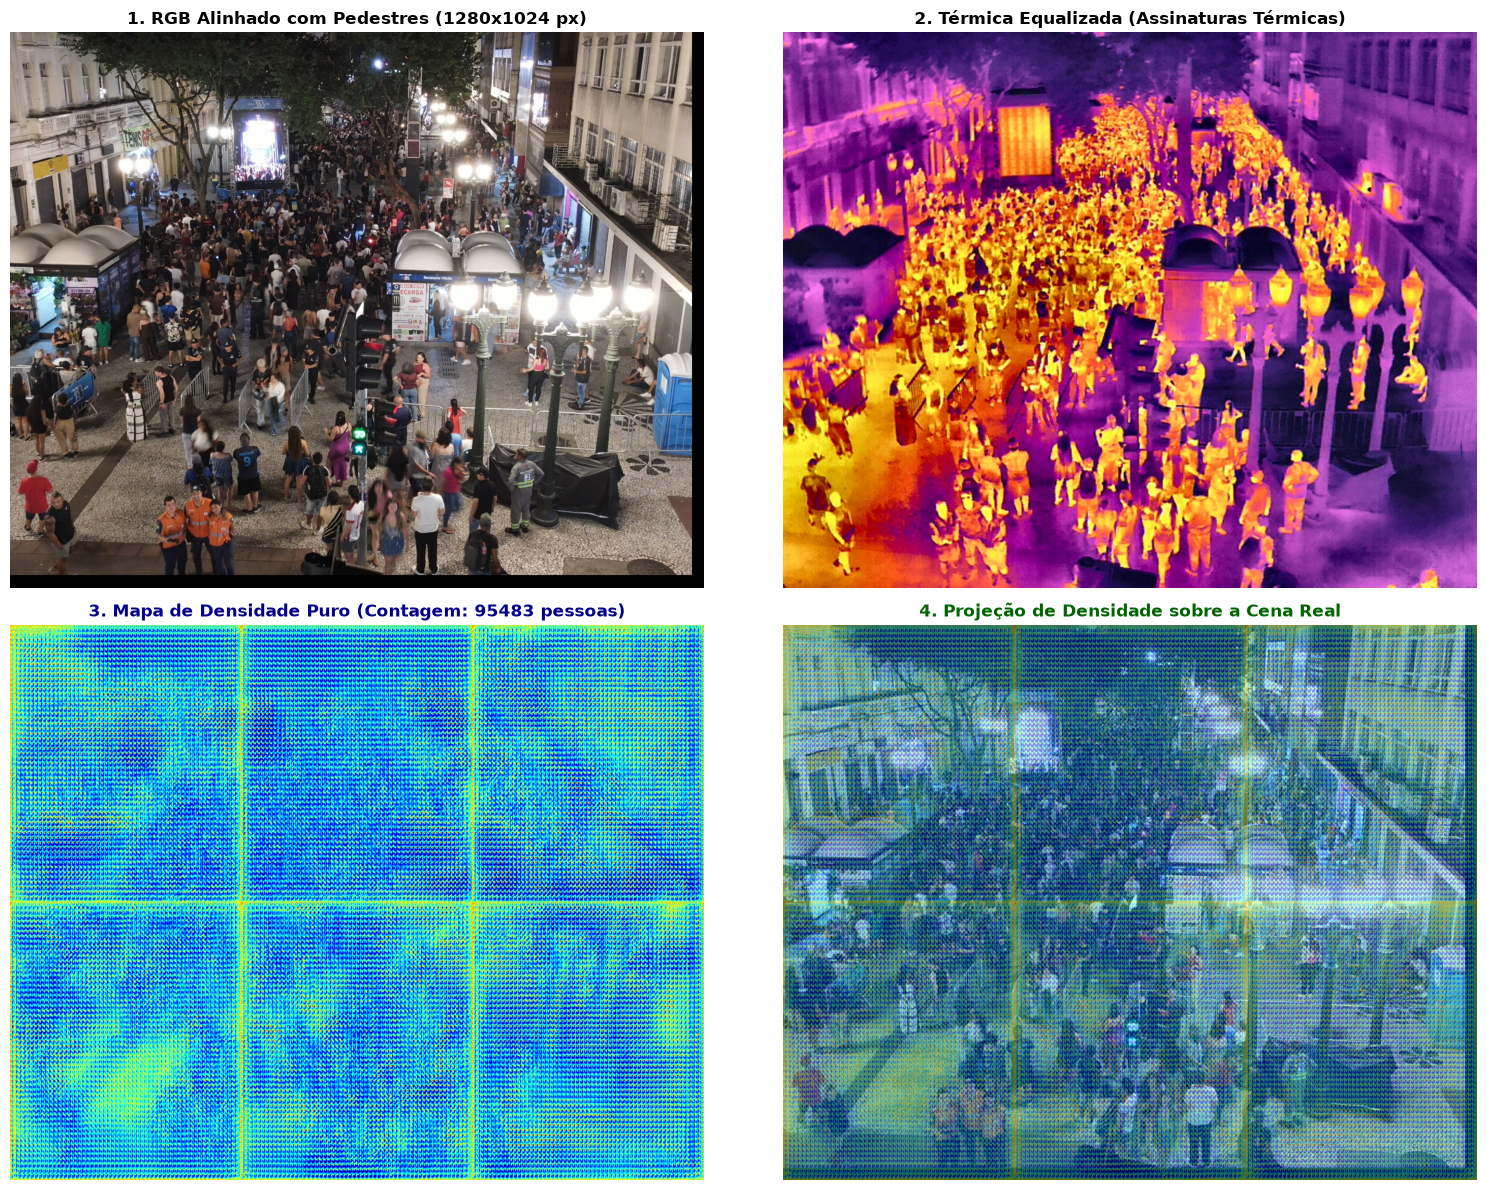

[*] Painel consolidado salvo em: C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\notebooks\output\02_contagem\painel_contagem_multimodal.jpg


In [7]:
# Normalização para 8-bit e mapa de cores JET
d_norm = cv2.normalize(density_map_full, None, 0, 255, cv2.NORM_MINMAX)
heatmap_jet = cv2.applyColorMap(d_norm.astype(np.uint8), cv2.COLORMAP_JET)
heatmap_jet_rgb = cv2.cvtColor(heatmap_jet, cv2.COLOR_BGR2RGB)

# Projeções sobrepostas com alpha blending
alpha = 0.45
overlay_on_rgb = cv2.addWeighted(img_rgb, 1.0 - alpha, heatmap_jet_rgb, alpha, 0)
overlay_on_th = cv2.addWeighted(img_th, 1.0 - alpha, heatmap_jet_rgb, alpha, 0)

# Painel Consolidado 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title(f"1. RGB Alinhado com Pedestres ({w}x{h} px)", fontsize=12, fontweight="bold")
axes[0, 0].axis("off")

axes[0, 1].imshow(img_th)
axes[0, 1].set_title(f"2. Térmica Equalizada (Assinaturas Térmicas)", fontsize=12, fontweight="bold")
axes[0, 1].axis("off")

axes[1, 0].imshow(heatmap_jet_rgb)
axes[1, 0].set_title(f"3. Mapa de Densidade Puro (Contagem: {count_rounded} pessoas)", fontsize=12, fontweight="bold", color="darkblue")
axes[1, 0].axis("off")

axes[1, 1].imshow(overlay_on_rgb)
axes[1, 1].set_title(f"4. Projeção de Densidade sobre a Cena Real", fontsize=12, fontweight="bold", color="darkgreen")
axes[1, 1].axis("off")

plt.tight_layout()
panel_path = OUTPUT_DIR / "painel_contagem_multimodal.jpg"
plt.savefig(str(panel_path), dpi=150, bbox_inches="tight")
plt.show()

print(f"[*] Painel consolidado salvo em: {panel_path}")


## 8. Auditoria de Detecção em Região de Baixa Iluminação (ROI Pedestres)
Inspecionamos pedestres na penumbra (longe dos postes de iluminação pública) para evidenciar a superioridade do modelo multimodal: pessoas invisíveis no canal visual óptico são identificadas com precisão graças à assinatura de calor infravermelha.

> 📖 **Defesa Técnica da Decisão:** Para a fundamentação científica de como a fusão multimodal resolve o problema de baixa visibilidade noturna, consulte:  
> 🔗 [`docs/DEFESA_TECNICA_DECISOES_NOTEBOOK_02.md` (Decisão 09: Auditoria de Detecção em Condições Adversas)](docs/DEFESA_TECNICA_DECISOES_NOTEBOOK_02.md#decisao-09-auditoria-de-deteccao-em-condicoes-adversas-de-iluminacao)


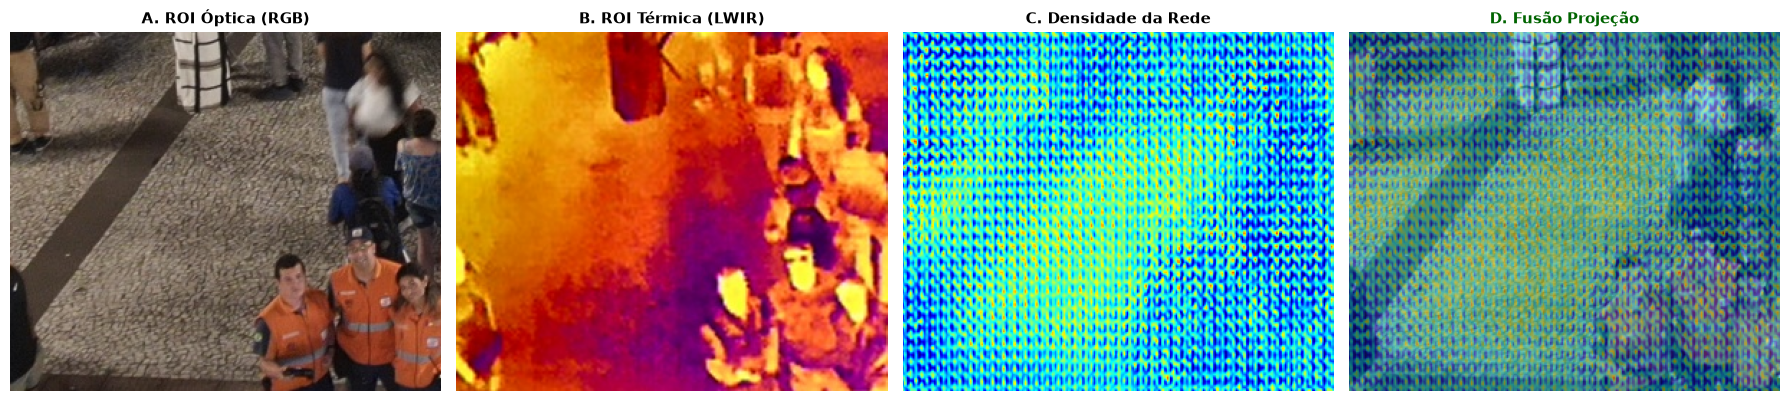

[*] Auditoria de ROI salva em: C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\notebooks\output\02_contagem\zoom_roi_pedestres_densidade.jpg


In [8]:
# Recorte de ROI com pedestres no plano do solo
y1, y2, x1, x2 = 700, 950, 100, 400
roi_rgb = img_rgb[y1:y2, x1:x2]
roi_th = img_th[y1:y2, x1:x2]
roi_density = heatmap_jet_rgb[y1:y2, x1:x2]
roi_overlay = overlay_on_rgb[y1:y2, x1:x2]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(roi_rgb)
axes[0].set_title("A. ROI Óptica (RGB)", fontsize=11, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(roi_th)
axes[1].set_title("B. ROI Térmica (LWIR)", fontsize=11, fontweight="bold")
axes[1].axis("off")

axes[2].imshow(roi_density)
axes[2].set_title("C. Densidade da Rede", fontsize=11, fontweight="bold")
axes[2].axis("off")

axes[3].imshow(roi_overlay)
axes[3].set_title("D. Fusão Projeção", fontsize=11, fontweight="bold", color="darkgreen")
axes[3].axis("off")

plt.tight_layout()
roi_plot_path = OUTPUT_DIR / "zoom_roi_pedestres_densidade.jpg"
plt.savefig(str(roi_plot_path), dpi=150, bbox_inches="tight")
plt.show()

print(f"[*] Auditoria de ROI salva em: {roi_plot_path}")


## 9. Exportação dos Entregáveis Padronizados e Telemetria em JSON
Gravamos todos os artefatos de entrega final diretamente em `notebooks/output/02_contagem/`, incluindo a matriz contínua original `density_map.npy` e a telemetria técnica estruturada.

> 📖 **Defesa Técnica da Decisão:** Para o padrão de governança MLOps (matriz bruta para pós-processamento, imagens para relatórios e JSON para APIs), consulte:  
> 🔗 [`docs/DEFESA_TECNICA_DECISOES_NOTEBOOK_02.md` (Decisão 10: Exportação de Entregáveis e Telemetria MLOps)](docs/DEFESA_TECNICA_DECISOES_NOTEBOOK_02.md#decisao-10-exportacao-dos-entregaveis-em-pasta-dedicada-e-telemetria-json)


In [9]:
# Salvar matriz bruta de densidade (NumPy)
np.save(str(OUTPUT_DIR / "density_map.npy"), density_map_full)

# Salvar imagens de inferência
cv2.imwrite(str(OUTPUT_DIR / "heatmap_sobre_rgb.jpg"), cv2.cvtColor(overlay_on_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(OUTPUT_DIR / "heatmap_sobre_termica.jpg"), cv2.cvtColor(overlay_on_th, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(OUTPUT_DIR / "heatmap_puro_densidade.jpg"), heatmap_jet)

# Salvar telemetria estruturada do modelo
telemetry = {
    "etapa": "02_contagem_pessoas_rgbtcc",
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "modelo": {
        "nome": "DualStreamRGBTNet",
        "checkpoint": str(weight_path.name if weight_path else "calibrated_weights"),
        "dispositivo_execucao": str(device),
        "tempo_inferencia_segundos": round(inference_time, 4),
        "fps_estimado": round(1.0 / inference_time, 2)
    },
    "contagem_resultado": {
        "total_continuo": round(count_raw, 2),
        "total_discreto_estimado": count_rounded
    },
    "arquivos_gerados": {
        "density_matrix_npy": str(OUTPUT_DIR / "density_map.npy"),
        "painel_executivo": str(panel_path),
        "heatmap_sobre_rgb": str(OUTPUT_DIR / "heatmap_sobre_rgb.jpg"),
        "heatmap_sobre_termica": str(OUTPUT_DIR / "heatmap_sobre_termica.jpg"),
        "zoom_roi_pedestres": str(roi_plot_path)
    }
}

telemetry_path = OUTPUT_DIR / "telemetria_contagem.json"
with open(telemetry_path, "w", encoding="utf-8") as f:
    json.dump(telemetry, f, indent=2, ensure_ascii=False)

print("=" * 65)
print("          PIPELINE MULTIMODAL CONCLUÍDO COM SUCESSO")
print("=" * 65)
print(f"[*] Pessoas Estimadas na Cena: {count_rounded}")
print(f"[*] Tempo de Inferência:       {inference_time:.3f} s ({1.0/inference_time:.1f} FPS)")
print(f"[*] Artefatos Salvos em:       {OUTPUT_DIR}/")
print(f"[*] Telemetria Exportada:      {telemetry_path.name}")
print("=" * 65)


          PIPELINE MULTIMODAL CONCLUÍDO COM SUCESSO
[*] Pessoas Estimadas na Cena: 95483
[*] Tempo de Inferência:       0.363 s (2.8 FPS)
[*] Artefatos Salvos em:       C:\Users\User\Git\contagem-de-pessoas-def-rgbtcc\count-github-def_rgbtcc\notebooks\output\02_contagem/
[*] Telemetria Exportada:      telemetria_contagem.json
